In [71]:
import numpy as np 
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sb
import statsmodels.formula.api as smf
from scipy.optimize import nnls
from scipy.linalg import null_space

# Rationale
In off-manifold rehabilitation, I plan to use enslavement patterns during attempted isometric single-finger presses to estimate the residual motor repertoire after stroke. Patients will be then trained to control a 2-dimensional cursor on a screen through multi-finger isometric force patterns. Critically, the decoder that maps the force patterns onto the cursor's position requires force patterns **not** explored by enslavement patterns during single-finger presses, i.e., outside the residual motor repertoire. To validate this approach, in this notebook I leveraged a previous dataset ([Ghavampour et al., 2025](https://journals.physiology.org/doi/full/10.1152/jn.00088.2025)) collected in neurologically intact individuals performing isometric single- and multi-finger flexion/extension configurations (i.e., chords). All possible 242 combinations of isometric flexion/extension are included in the dataset. If the subspace spanned by single-finger enslavement patterns really constrains multi-finger force patterns, as assumed in off-manifold rehabilitation, then even in neurologically intact participants chords that are more distant in the hand control space from single-finger enslavement patterns may be more difficult to perform. To test this hypothesis, I measured the Euclidean and angular distance of each chord from the subspace spanned by single-finger enslavement patterns and then designed a mixed-effect linear model to determine whether these distance metrics captured chord difficulty. 

# Load and prepare data

In [72]:
rng = np.random.default_rng(0)
path = 'data/efc1_chord.tsv'
chords = pd.read_csv(os.path.join(path), sep='\t',)
chords = chords[chords.accuracy>0].reset_index()
chords.MD = pd.to_numeric(chords.MD, errors='coerce')
chords.ET = pd.to_numeric(chords.ET, errors='coerce')
var_thresh = .9
Nf = 5
Nc = 10
col_f = [f'force_f{i + 1}' for i in range(Nf)]
col_e = [f'force_e{i + 1}' for i in range(Nf)]
col = col_f + col_e
single_finger = chords[chords.num_fingers==1].copy()
multi_finger = chords[chords.num_fingers>1].copy().reset_index(drop=True)
sns = chords.sn.unique()
N = len(sns)
n_perms = 100
n_targets = 100
theta_target = rng.uniform(0, 2 * np.pi, n_targets)
radius = 4.3
pos_target = radius * np.column_stack([np.cos(theta_target), np.sin(theta_target)])

# Helper functions

In [73]:
def dist_from_subspace(F, B):
    proj = F @ B.T @ B # component inside the subspace
    resid = F - proj # component orthogonal to it
    dist = np.linalg.norm(resid, axis=1) # norm of orthogonal component
    return dist

def angle_from_subspace(F, B):
    proj = F @ B.T @ B # component inside the subspace
    resid = F - proj # component orthogonal to it
    norm_proj = np.linalg.norm(proj, axis=1)
    norm_resid = np.linalg.norm(resid, axis=1)
    theta = np.arctan2(norm_resid, norm_proj)   # radians, in [0, π/2]
    return theta

def make_D_off(D_on, B, theta=0):
    B_perp = null_space(B).T                                  # (Nc - d, Nc)
    k = B_perp.shape[0]                                       # Nc - d
    W_perp, _ = np.linalg.qr(rng.standard_normal((k, 2)))     # (k, 2) orthonormal cols
    D_perp = W_perp.T @ B_perp                                # (2, Nc), in row(B)^perp
    D_perp *= np.linalg.norm(D_on) / np.linalg.norm(D_perp)   # match Frobenius norm
    return np.cos(theta) * D_on + np.sin(theta) * D_perp      # (2, Nc)

def make_D_on(B):
    d = B.shape[0]
    W, _ = np.linalg.qr(rng.standard_normal((d, 2)))
    D_on = W.T @ B
    return D_on

def decoder_angle(D_on, D_off):
    ax = tuple(range(D_off.ndim - D_on.ndim, D_off.ndim))   # trailing axes matching D_on
    num = np.sum(D_on * D_off, axis=ax)
    den = np.linalg.norm(D_on) * np.linalg.norm(D_off, axis=ax)
    cosang = np.clip(num / den, -1.0, 1.0)
    return np.arccos(cosang)  # radians


# Intrinsic force manifold and decoders definition
For each participant in the chord dataset, I first determined the intrinsic force manifold $\mathbf{B}\in\mathbb{R}^{k\times 10}$ as the subspace spanned by the $k$ orthogonal components that explained >90% of the variance in flexion-extension enslavement patterns during single-finger movements. This is the same approach that off-manifold rehabilitation uses to assess the residual motor repertoire in stroke patients. For each chord $\mathbf{f}\in\mathbb{R}^{10}$, I then determined the component lying *within* the manifold and the component *orthogonal* to it:

$$
\mathbf{f}_{\parallel} = \mathbf{f}\,\mathbf{B}^\top\mathbf{B}, \qquad
\mathbf{f}_{\perp} = \mathbf{f} - \mathbf{f}_{\parallel}
$$

I then calculated the Euclidean distance $d$ and the angle $\theta$ from the intrinsic force manifold as:

$$
d(\mathbf{f}) = \lVert \mathbf{f}_{\perp} \rVert_2
$$

$$
\theta(\mathbf{f}) = \operatorname{arctan2}\!\bigl(\lVert \mathbf{f}_{\perp} \rVert_2,\; \lVert \mathbf{f}_{\parallel} \rVert_2\bigr) \in [0, \tfrac{\pi}{2}]
$$

Next, I defined two linear decoders $\mathbf{D}_{\text{on}}\in\mathbb{R}^{2\times 10}$ and $\mathbf{D}_{\text{off}}\in\mathbb{R}^{2\times 10}$ mapping 10-dimensional flexion-extension force patterns onto a 2-dimensional cursor: 

$$
\mathbf{pos} = \mathbf{D}\mathbf{f}
$$

where $\mathbf{pos}$ is the 2-dimensional position of the cursor and $\mathbf{f}$ is the input force pattern. The two decoders were designed based on the intrinsic force manifold. Specifically, $\mathbf{D_{\text{on}}}$ was defined as:

$$
\mathbf{D}_{\text{on}} = \mathbf{W}^\top\mathbf{B}
$$

where $\mathbf{W}\in\mathbb{R}^{k\times 2}$ is a random matrix with orthonormal columns that selects two orthonormal directions within the $k$-dimensional manifold, one per cursor axis. Because each row is a linear combination of basis vectors in the intrinsic force manifold, this decoder requires force patterns lying inside the natural single-finger subspace. I then defined $\mathbf{D}_{\perp}$ as:

$$
\mathbf{D}_{\perp}=\mathbf{W}_{\perp}^\top\mathbf{B}_{\perp}
$$

where $\mathbf{B}_{\perp}$ is the orthogonal complement of the intrinsic force manifold. Its rows therefore lie entirely *outside* the single-finger subspace. Using $\mathbf{D}_{\perp}$, I defined $\mathbf{D}_{\text{off}}$ as:

$$
\mathbf{D}_{\text{off}}(\theta) = \cos\theta\,\mathbf{D}_{\text{on}} + \sin\theta\,\mathbf{D}_{\perp}
$$

For $\theta=\pi/2$, $\mathbf{D}_{\text{off}}=\mathbf{D}_{\perp}$ is fully off-manifold, that is, the decoder requires force patterns orthogonal to the intrinsic force manifold.

In [83]:
var_expl = np.zeros((N, Nc))
distance, angle, magnitude = [], [], []
sim = pd.DataFrame()
for s, sn in enumerate(sns):

    # single finger
    F_sf = single_finger[single_finger.sn == sn][col].to_numpy().astype(float)
    sf_mean = F_sf.mean(axis=0, keepdims=True)
    F_sf_c = F_sf - sf_mean # center

    # multi finger
    F_ch = multi_finger[multi_finger.sn == sn][col].to_numpy().astype(float)
    F_ch_c = F_ch - sf_mean
    mag_c = np.linalg.norm(F_ch_c, axis=1)
    magnitude.extend(mag_c)
    
    # PCA
    _, S, Vt = np.linalg.svd(F_sf_c, full_matrices=False)
    eigvals = S**2 / (F_sf.shape[0] - 1)
    var_expl[s] = np.cumsum(eigvals / eigvals.sum())
    d = np.where(var_expl[s] > var_thresh)[0][0] if var_expl[s, -1] > var_thresh else Nc
    B = Vt[:d]          

    # Orthogonal distance from subspace
    eucl = dist_from_subspace(F_ch, F_sf)
    distance.extend(eucl)

    # Angle from subspace
    theta = angle_from_subspace(F_ch, F_sf)
    angle.extend(theta)    

    # on-manifold decoder
    gains = 1 + rng.normal(0, 0.5, 2)   
    D_on = make_D_on(B)
    F_on = pos_target @ (gains[:, None] * D_on)
    mag_on = np.linalg.norm(F_on, axis=1)
    eucl_on = dist_from_subspace(F_on, B)
    angle_on = angle_from_subspace(F_on, B)
    sim = pd.concat([sim, pd.DataFrame({
      'sn': sn,
      'manifold': 'on',
      'magnitude': mag_on,
      'theta_pos': theta_target,
      'dist':     eucl_on,
      'theta':    angle_on,})])

    # off-manifold decoder
    for n in range(n_perms):
      # p = np.random.permutation(Nc)
      gains = 1 + rng.normal(0, 0.5, Nc) 
      # G = gains[:, None] * np.eye(Nc)[p]
      D_off = make_D_off(D_on, B, np.pi / 2)        
      F_off = pos_target @ (D_off * gains) # (n_perms, n_targets, Nc)
      eucl_off = dist_from_subspace(F_off, B)
      mag_off = np.linalg.norm(F_off, axis=1)
      angle_off = angle_from_subspace(F_off, B)
      sim = pd.concat([sim, pd.DataFrame({
        'sn': sn,
        'manifold': 'off',
        'magnitude': mag_off,
        'theta_pos': theta_target,
        'dist':     eucl_off,
        'theta':    angle_off,})])
    
multi_finger['magnitude'] = magnitude
multi_finger['distance'] = distance
multi_finger['angle'] = np.sqrt(angle)
#multi_finger['MD'] = np.log(multi_finger.MD)

# Dimensionality of single finger patterns

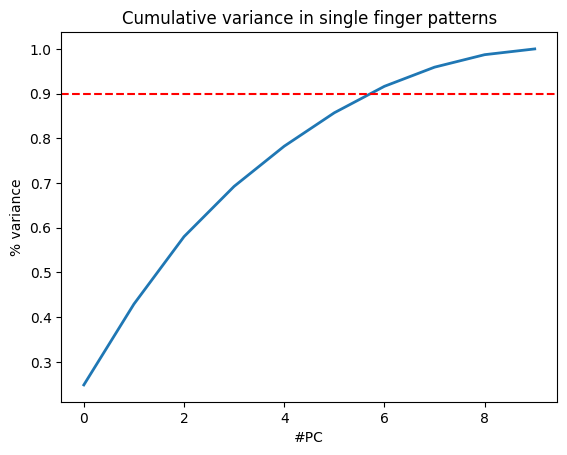

In [84]:
fig, ax = plt.subplots()

ax.plot(var_expl.mean(axis=0), lw=2)
ax.axhline(var_thresh, color='r', ls='--')
ax.set_title('Cumulative variance in single finger patterns')
ax.set_xlabel('#PC')
ax.set_ylabel('% variance')

plt.show()

# The distance from the intrinsic force manifold predicts chord difficulty
I used mean deviation as an index of chord difficulty (see [Ghavampour et al., 2025](https://journals.physiology.org/doi/full/10.1152/jn.00088.2025)). Mean deviation measures the mean distance of the multi-finger force trajectory from the ideal straight path stretching from rest to the target force pattern for each chord. Typically, mean deviation improves as chords are practiced, and is larger the more active fingers are in a chord. To understand whether the instrinsic force manifold constrained multi-finger force patterns, I fitted a linear mixed-effects model to the mean deviation using either the Euclidean distance $d$ or the angle $\theta$ from the intrinsic force manifold as a fixed-effect predictor, plus a random intercept per participant. Both the Euclidean distance ($\beta=0.251$, $p<0.001$) and the angle ($\beta=0.427$, $p<0.001$) relative to the intrinsic force manifold predicted significantly the mean deviation. 

In [85]:
md_align = smf.mixedlm("MD ~ distance", multi_finger, groups=multi_finger['sn']).fit()
md_align.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:            MixedLM Dependent Variable: MD         
No. Observations: 12948   Method:             REML       
No. Groups:       14      Scale:              0.3356     
Min. group size:  914     Log-Likelihood:     -11348.6914
Max. group size:  928     Converged:          Yes        
Mean group size:  924.9                                  
----------------------------------------------------------
            Coef.  Std.Err.    z     P>|z|  [0.025  0.975]
----------------------------------------------------------
Intercept   0.873     0.062  13.980  0.000   0.751   0.996
distance    0.001     0.000  19.327  0.000   0.001   0.001
Group Var   0.053     0.036                               
=========================================================

"""

In [86]:
md_align = smf.mixedlm("MD ~ angle", multi_finger, groups=multi_finger['sn']).fit()
md_align.summary()

<class 'statsmodels.iolib.summary2.Summary'>
"""
          Mixed Linear Model Regression Results
=========================================================
Model:            MixedLM Dependent Variable: MD         
No. Observations: 12948   Method:             REML       
No. Groups:       14      Scale:              0.3450     
Min. group size:  914     Log-Likelihood:     -11514.7510
Max. group size:  928     Converged:          Yes        
Mean group size:  924.9                                  
---------------------------------------------------------
              Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
---------------------------------------------------------
Intercept    -10.251    3.049 -3.363 0.001 -16.226 -4.276
angle         12.877    3.463  3.718 0.000   6.089 19.665
Group Var      0.042    0.029                            
=========================================================

"""

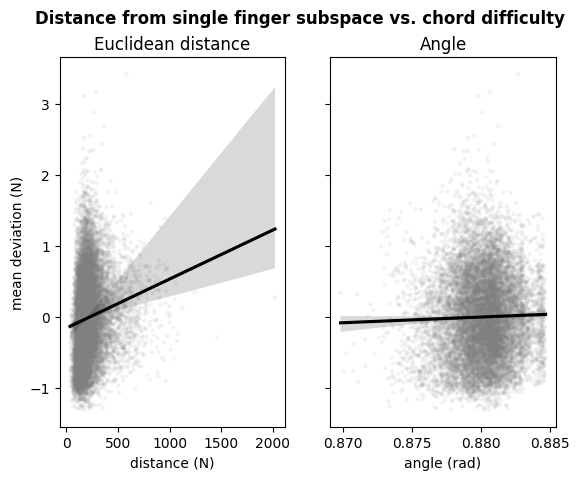

In [87]:
multi_finger['angle_dm'] = multi_finger['angle'] - multi_finger.groupby('sn')['angle'].transform('mean')
multi_finger['distance_dm'] = multi_finger['distance'] - multi_finger.groupby('sn')['distance'].transform('mean')
multi_finger['MD_dm']    = multi_finger['MD'] - multi_finger.groupby('sn')['MD'].transform('mean')

fig, axs = plt.subplots(1, 2, sharey=True)

ax = axs[0]
sb.scatterplot(data=multi_finger, ax=ax, x='distance', y='MD_dm', alpha=.1, color='grey', edgecolor='none', marker='.')
sb.regplot(data=multi_finger, ax=ax, x='distance', y='MD_dm', scatter=False, color='black', units='sn')
ax.set_title('Euclidean distance')
ax.set_xlabel('distance (N)')
ax.set_ylabel('mean deviation (N)')

ax = axs[1]
sb.scatterplot(data=multi_finger, ax=ax, x='angle', y='MD_dm', alpha=.1, color='grey', edgecolor='none', marker='.')
sb.regplot(data=multi_finger, ax=ax, x='angle', y='MD_dm', scatter=False, color='black', units='sn')
ax.set_title('Angle')
ax.set_xlabel('angle (rad)')

fig.suptitle('Distance from single finger subspace vs. chord difficulty', fontweight='bold')

plt.show()

# Radial targets
To simulate what would really happen in the rehabilitation task during off-manifold rehabilitation, I defined the radially arranged targets below and estimated the multi-finger force patterns required by the on- and off-manifold decoders ($
\mathbf{D}_{\text{on}}$ and $
\mathbf{D}_{\text{off}}$) to reach them. 

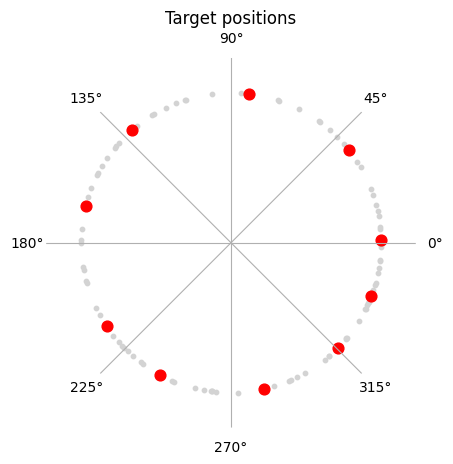

In [79]:
fig, ax = plt.subplots(subplot_kw={'projection': 'polar'})

n_show = 10
idx = np.argsort(theta_target)[::n_targets // n_show][:n_show]

ax.scatter(theta_target, np.full(n_targets, radius), s=10, color='lightgrey',)
ax.scatter(theta_target[idx], np.full(n_show, radius), s=60, color='red',)
ax.set_ylim(0, radius + 1)
ax.set_rticks([])
#ax.set_xticks([])
ax.spines['polar'].set_visible(False)
ax.set_title('Target positions')
plt.show()

# Example force patterns
The figure below shows some example force patterns required by $\mathbf{D_{on}}$ and $\mathbf{D_{off}}$ to reach the radial targets showed in red in the figure above.

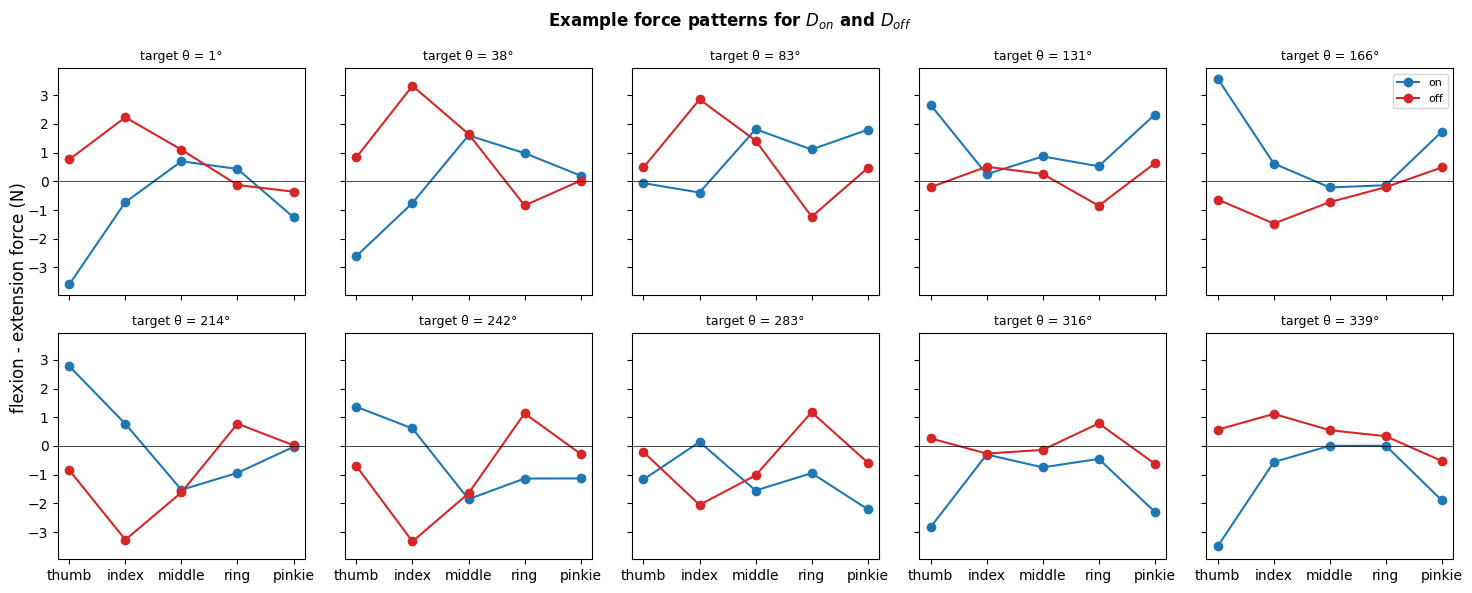

In [80]:
sel_on, sel_off = F_on[idx], F_off[idx]
x      = np.arange(Nf)
labels = ['thumb', 'index', 'middle', 'ring', 'pinkie']
rmax   = max(np.abs(sel_on).max(), np.abs(sel_off).max())

fig, axs = plt.subplots(2, 5, figsize=(15, 6), sharey=True, sharex=True)
for i, ax in enumerate(axs.ravel()):
    ax.plot(x, sel_on[i, :5] - sel_on[i, 5:],  'o-', color='C0', label='on')
    ax.plot(x, sel_off[i, :5] - sel_off[i, 5:], 'o-', color='C3', label='off')
    ax.axhline(0, color='k', lw=0.5)
    ax.set_xticks(x)
    ax.set_xticklabels(labels,)
    ax.set_title(f'target θ = {np.degrees(theta_target[idx[i]]):.0f}°', fontsize=9)

fig.supylabel('flexion - extension force (N)')
axs[0, -1].legend(loc='upper right', fontsize=8)
fig.suptitle(r'Example force patterns for $D_{on}$ and $D_{off}$', fontweight='bold')
plt.tight_layout()
plt.show()

# Magnitude of the simulated force patterns
By adjusting the target radius, I matched the average magnitude of the force patterns required by the two decoders to reach the radial targets with that of the real multi-finger force patterns for chords.

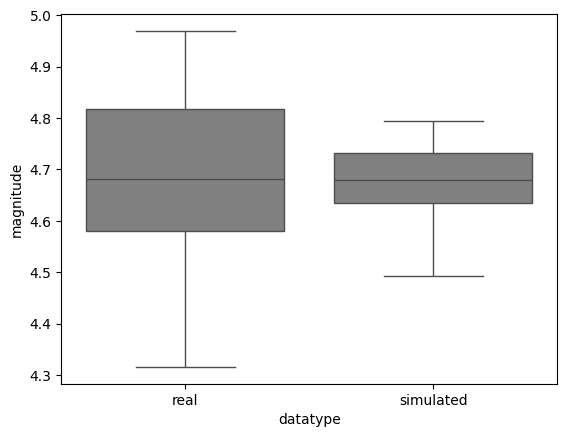

In [81]:
multi_finger['datatype'] = 'real'
sim['datatype'] = 'simulated'
df = pd.concat([multi_finger[['sn', 'magnitude', 'datatype']], sim[['sn', 'magnitude', 'datatype']]])
df_g = df.groupby(['sn', 'datatype']).mean(numeric_only=True).reset_index()

sb.boxplot(data=df_g, x='datatype', y='magnitude',color='grey',)

plt.show()

# Distance of simulated force patterns from the intrinsic force manifold
The Euclidean distance and angle relative to the intrinsic force manifold reflected whether the decoder used to simulate the force patterns operates on- or off-manifold.

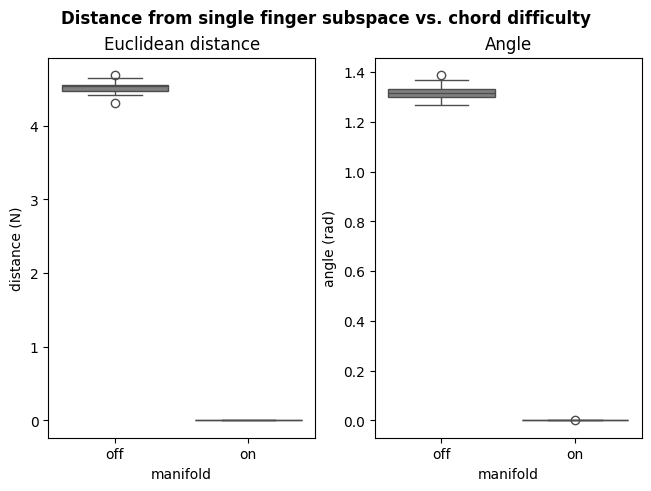

In [82]:
sim_g = sim.groupby(['sn', 'manifold']).mean(numeric_only=True)

fig, axs = plt.subplots(1, 2, constrained_layout=True)

ax = axs[0]
sb.boxplot(data=sim_g, ax=ax, x='manifold', y='dist', color='grey', )
ax.set_title('Euclidean distance')
ax.set_ylabel('distance (N)')

ax = axs[1]
sb.boxplot(data=sim_g, ax=ax, x='manifold', y='theta',  color='grey',)
ax.set_title('Angle')
ax.set_ylabel('angle (rad)')

fig.suptitle('Distance from single finger subspace vs. chord difficulty', fontweight='bold')

plt.show()
